# Sessions Inventory: Analysis & Statistics

Built for the actual `sessions_inventory.json` schema: a **list of session records**, each with
scalar fields (`session_id`, `session_date`, `child_id`, `session_type`, `session_number`) plus
**nested file-listing fields** (`all_files`, `all_folders`, `mkv_files`, `audio_files`,
`json_files`, `eaf_files`, `txt_files`, `folder_structure`) and explicit availability flags
(`bounding_boxes_folder_available`, `skeletons_folder_available`,
`Visualizations_folder_available`, `config_reid_json_available`).

In [1]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set global styles
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
plt.rcParams.update({'font.size': 10, 'figure.titlesize': 14})

JSON_PATH = 'sessions_inventory.json'

In [2]:
# 1. LOAD & CLEAN DATA
# ==========================================
with open(JSON_PATH, "r", encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))

def canonicalize_child_id(child_id_str):
    """Normalizes group IDs (e.g., '10-17' and '17-10' -> '10-17')."""
    if pd.isna(child_id_str) or not isinstance(child_id_str, str):
        return np.nan
    ids = re.findall(r"\d+", child_id_str)
    return "-".join(map(str, sorted(map(int, ids)))) if len(ids) > 1 else child_id_str

def parse_session_date(date_str):
    """Parses session dates supporting multiple string formats."""
    if pd.isna(date_str):
        return pd.NaT
    for fmt in ("%Y-%m-%d", "%d-%m-%Y", "%Y/%m/%d", "%d/%m/%Y"):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except ValueError:
            continue
    return pd.to_datetime(date_str, errors="coerce")

df_clean = df.copy()

# Canonicalize child IDs
if "child_id" in df_clean.columns:
    df_clean["child_id_canonical"] = df_clean["child_id"].apply(canonicalize_child_id)

# Extract counts from nested lists
nested_list_cols = ['all_files', 'all_folders', 'mkv_files', 'audio_files', 'json_files', 'eaf_files', 'txt_files']
for col in nested_list_cols:
    if col in df_clean.columns:
        df_clean[f'n_{col}'] = df_clean[col].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Convert boolean flags
bool_cols = [col for col in df_clean.columns if 'available' in col.lower()]
df_clean[bool_cols] = df_clean[bool_cols].fillna(False).astype(bool)

# Deduplicate
sort_col = "n_txt_files" if "n_txt_files" in df_clean.columns else "session_id"
df_clean = df_clean.sort_values(by=sort_col, ascending=False).drop_duplicates(subset=["session_id"], keep="first")

# Parse session dates
if "session_date" in df_clean.columns:
    df_clean["session_date"] = df_clean["session_date"].apply(parse_session_date)
    df_clean["year_month"] = df_clean["session_date"].dt.to_period("M").astype(str)

In [17]:
# 2. TABLES SUMMARY
# ==========================================

print("\n" + "="*60)
print(" TABLE 1: Missing Data Summary ")
print("="*60)
missing_df = pd.DataFrame({
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Pct (%)': (df_clean.isnull().mean() * 100).round(2)
})
print(missing_df[missing_df['Missing_Count'] > 0])

print("\n" + "="*60)
print(" TABLE 2: Feature & Directory Availability Rate ")
print("="*60)
if bool_cols:
    avail_df = pd.DataFrame({
        'Available_Sessions': df_clean[bool_cols].sum(),
        'Availability_Pct (%)': (df_clean[bool_cols].mean() * 100).round(2)
    }).sort_values(by='Availability_Pct (%)', ascending=False)
    print(avail_df)

print("\n" + "="*60)
print(" TABLE 3: File Counts Summary Statistics ")
print("="*60)
count_cols = [c for c in df_clean.columns if c.startswith('n_')]
if count_cols:
    stats_df = df_clean[count_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
    stats_df.rename(columns={'50%': 'median'}, inplace=True)
    print(stats_df.round(2))

print("\n" + "="*60)
print(" TABLE 4: Children by Session Count ")
print("="*60)
if "child_id_canonical" in df_clean.columns:
    child_summary = df_clean.groupby("child_id_canonical").agg(
        session_count=("session_id", "count"),
        total_mkv=("n_mkv_files", "sum") if "n_mkv_files" in df_clean.columns else ("session_id", "count"),
        total_eaf=("n_eaf_files", "sum") if "n_eaf_files" in df_clean.columns else ("session_id", "count")
    ).sort_values(by="session_count", ascending=False)
    print(child_summary)


 TABLE 1: Missing Data Summary 
Empty DataFrame
Columns: [Missing_Count, Missing_Pct (%)]
Index: []

 TABLE 2: Feature & Directory Availability Rate 
                                 Available_Sessions  Availability_Pct (%)
config_reid_json_available                       27                  9.28
bounding_boxes_folder_available                   5                  1.72
skeletons_folder_available                        5                  1.72
Visualizations_folder_available                   1                  0.34

 TABLE 3: File Counts Summary Statistics 
               count    mean      std  min  median      max
n_all_files    291.0  196.65  1514.62  0.0     4.0  14808.0
n_all_folders  291.0    0.12     0.82  0.0     0.0      7.0
n_mkv_files    291.0    2.00     0.22  0.0     2.0      4.0
n_audio_files  291.0    1.25     0.51  0.0     1.0      3.0
n_json_files   291.0   24.86   217.76  0.0     1.0   2886.0
n_eaf_files    291.0    0.19     0.63  0.0     0.0      4.0
n_txt_files    2

In [18]:
# CALCULATE CHILD-LEVEL METRICS
# ==========================================
# Group by child and calculate duration, videos, and sessions
child_metrics = df_clean.groupby("child_id_canonical").agg(
    min_date=("session_date", "min"),
    max_date=("session_date", "max"),
    number_of_sessions=("session_id", "nunique"),
    total_videos=("n_mkv_files", "sum") if "n_mkv_files" in df_clean.columns else ("session_id", "count")
).reset_index()

# Calculate duration in days 
child_metrics["therapy_duration"] = (
    (child_metrics["max_date"] - child_metrics["min_date"]).dt.days + 1
).astype(int)

# Sort by Therapy Duration (days) ascending as shown in the target plot
child_metrics = child_metrics.sort_values(by="therapy_duration", ascending=True).reset_index(drop=True)

child_metrics

,child_id_canonical,min_date,max_date,number_of_sessions,total_videos,therapy_duration
0,12-13,2023-11-28,2023-11-28,1,2,1
1,20,2024-01-30,2024-01-30,1,2,1
2,13,2024-06-18,2024-06-25,2,4,8
3,14-15,2023-11-15,2023-12-13,5,10,29
4,12-13-19,2023-11-07,2024-01-23,7,14,78
5,3,2024-03-21,2024-06-13,8,15,85
6,1,2024-03-21,2024-06-26,7,14,98
7,13-19,2024-01-30,2024-05-07,12,24,99
8,1-3,2023-11-09,2024-03-07,13,24,120
9,58,2024-11-14,2025-04-10,16,32,148


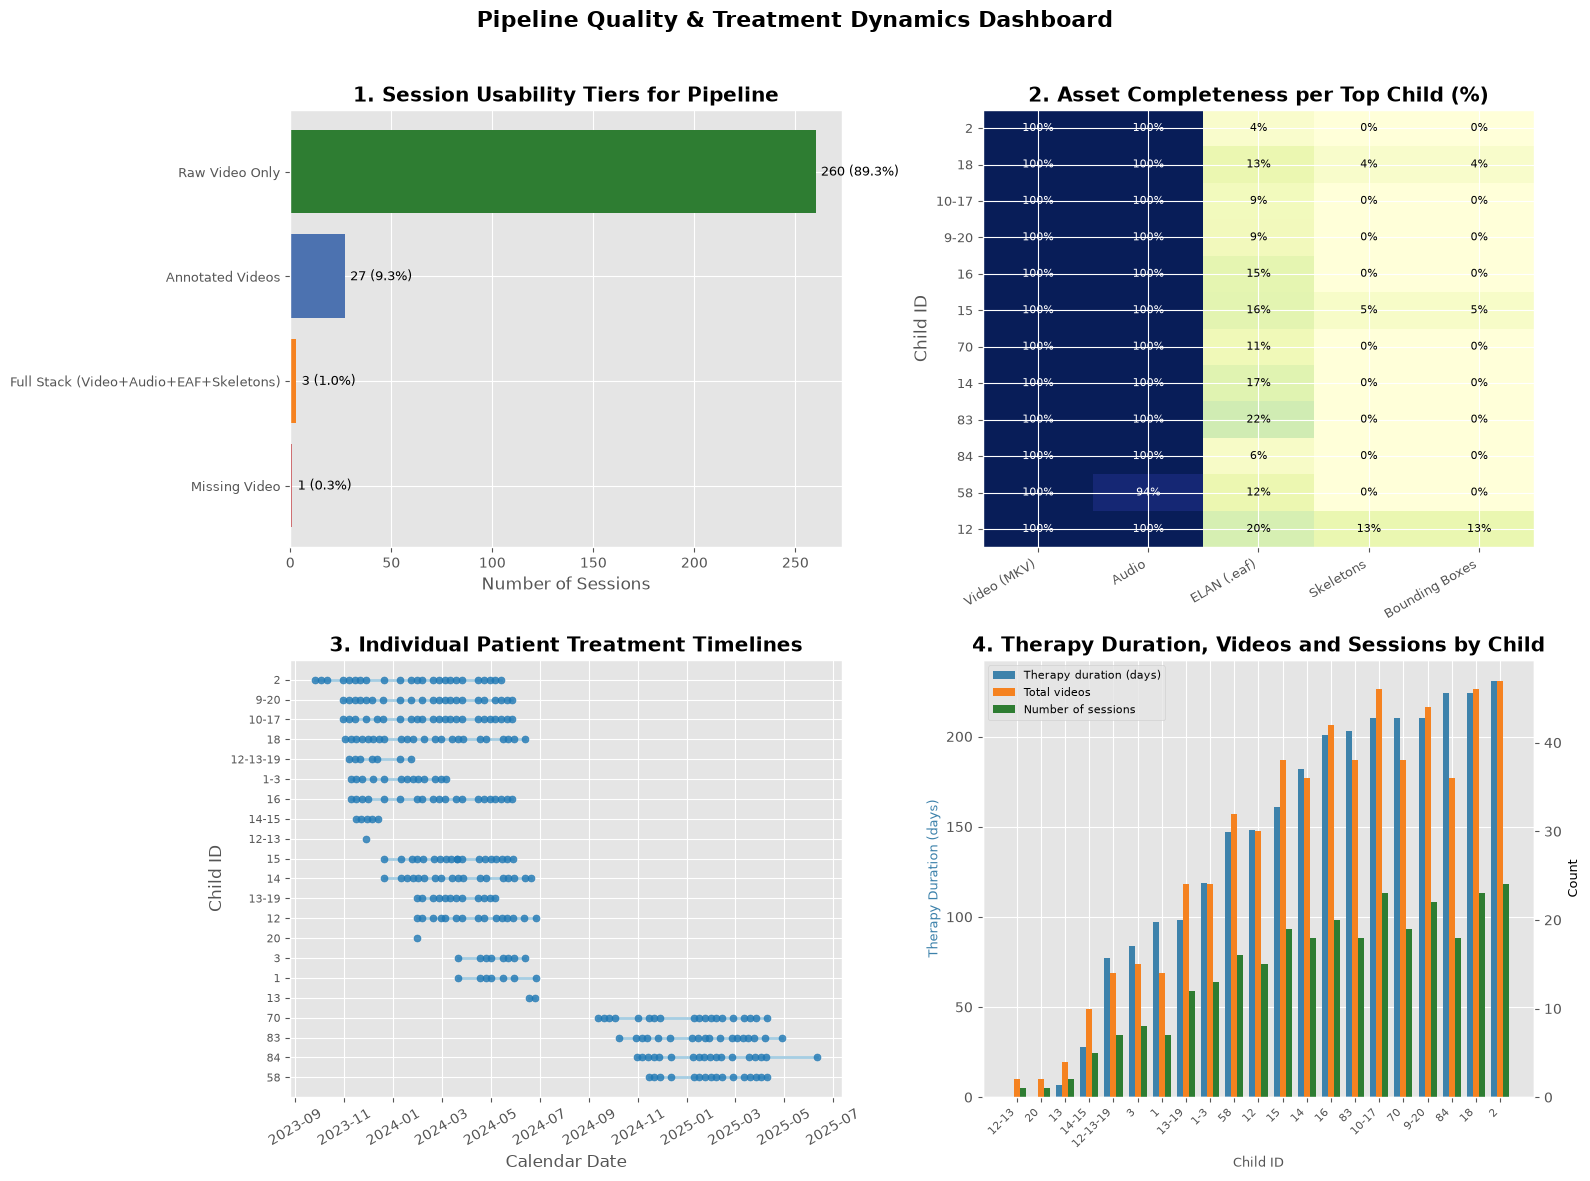

In [20]:
 # Set up 2x2 Grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Pipeline Quality & Treatment Dynamics Dashboard", fontsize=16, fontweight='bold')

# ==========================================
# PLOT 1: SESSION USABILITY TIERS FOR PIPELINE
# ==========================================

def assign_usability_tier(row):
    has_video = row.get("n_mkv_files", 0) > 0
    has_audio = row.get("n_audio_files", 0) > 0
    has_eaf = row.get("n_eaf_files", 0) > 0
    has_skeletons = bool(row.get("skeletons_folder_available", False))
    if has_video and has_audio and has_eaf and has_skeletons:
        return "Full Stack (Video+Audio+EAF+Skeletons)"
    elif has_video and has_eaf:
        return "Annotated Videos"
    elif has_video:
        return "Raw Video Only"
    else:
        return "Missing Video"

df_clean["usability_tier"] = df_clean.apply(assign_usability_tier, axis=1)
tier_counts = df_clean["usability_tier"].value_counts()
tier_colors = ["#2e7d32", "#4c72b0", "#f58220", "#c44e52"]
y_positions = np.arange(len(tier_counts))

axes[0, 0].barh(y_positions, tier_counts.values[::-1], color=tier_colors[::-1])
axes[0, 0].set_yticks(y_positions)
axes[0, 0].set_yticklabels(tier_counts.index[::-1], fontsize=9)
axes[0, 0].set_title("1. Session Usability Tiers for Pipeline", fontweight='bold')
axes[0, 0].set_xlabel("Number of Sessions")

max_val = max(tier_counts.values) if len(tier_counts) > 0 else 1
for i, val in enumerate(tier_counts.values[::-1]):
    pct = (val / len(df_clean)) * 100
    axes[0, 0].text(val + (max_val * 0.01), i, f"{val} ({pct:.1f}%)", va='center', fontsize=9)

# ==========================================
# PLOT 2: ASSET COMPLETENESS PER TOP CHILD (%)
# ==========================================

if "child_id_canonical" in df_clean.columns:
    top_children_ids = df_clean["child_id_canonical"].value_counts().head(12).index
    df_top = df_clean[df_clean["child_id_canonical"].isin(top_children_ids)]

    modalities = {
        'Video (MKV)': 'n_mkv_files',
        'Audio': 'n_audio_files',
        'ELAN (.eaf)': 'n_eaf_files',
        'Skeletons': 'skeletons_folder_available',
        'Bounding Boxes': 'bounding_boxes_folder_available'
    }

    heatmap_rows = []
    for child in top_children_ids:
        c_df = df_top[df_top["child_id_canonical"] == child]
        row_rates = []
        for m_name, m_col in modalities.items():
            if m_col in c_df.columns:
                if c_df[m_col].dtype == bool:
                    rate = c_df[m_col].mean() * 100
                else:
                    rate = (c_df[m_col] > 0).mean() * 100
            else:
                rate = 0.0
            row_rates.append(rate)
        heatmap_rows.append(row_rates)

    heatmap_arr = np.array(heatmap_rows)
    axes[0, 1].imshow(heatmap_arr, cmap="YlGnBu", aspect="auto", vmin=0, vmax=100)
    axes[0, 1].set_title("2. Asset Completeness per Top Child (%)", fontweight='bold')
    axes[0, 1].set_xticks(np.arange(len(modalities)))
    axes[0, 1].set_xticklabels(list(modalities.keys()), rotation=30, ha="right", fontsize=9)
    axes[0, 1].set_yticks(np.arange(len(top_children_ids)))
    axes[0, 1].set_yticklabels(top_children_ids, fontsize=9)
    axes[0, 1].set_ylabel("Child ID")

    for i in range(len(top_children_ids)):
        for j in range(len(modalities)):
            val = heatmap_arr[i, j]
            text_color = "white" if val > 60 else "black"
            axes[0, 1].text(j, i, f"{val:.0f}%", ha="center", va="center", color=text_color, fontsize=8)

# ==========================================
# PLOT 3: INDIVIDUAL PATIENT TREATMENT TIMELINES
# ==========================================
df_dyn = df_clean.dropna(subset=["session_date"]).copy()
df_dyn["session_date"] = pd.to_datetime(df_dyn["session_date"])

child_start_dates = df_dyn.groupby("child_id_canonical")["session_date"].min().sort_values(ascending=False)
ordered_children = child_start_dates.index.tolist()

ax3 = axes[1, 0]
for idx, child_id in enumerate(ordered_children):
    child_dates = df_dyn[df_dyn["child_id_canonical"] == child_id]["session_date"]
    min_d, max_d = child_dates.min(), child_dates.max()    

    # Draw line span from start to end session date
    ax3.plot([min_d, max_d], [idx, idx], color="#a6cee3", linewidth=2, zorder=1)
    # Plot individual session dates as dots
    ax3.scatter(child_dates, [idx] * len(child_dates), color="#1f78b4", s=25, alpha=0.8, zorder=2)

ax3.set_yticks(range(len(ordered_children)))
ax3.set_yticklabels(ordered_children, fontsize=8)
ax3.set_title("3. Individual Patient Treatment Timelines", fontweight='bold')
ax3.set_xlabel("Calendar Date")
ax3.set_ylabel("Child ID")
ax3.tick_params(axis='x', rotation=30)

# ==========================================

# PLOT 4: THERAPY DURATION, VIDEOS & SESSIONS BY CHILD

# ==========================================
child_metrics = df_clean.groupby("child_id_canonical").agg(
    min_date=("session_date", "min"),
    max_date=("session_date", "max"),
    number_of_sessions=("session_id", "nunique"),
    total_videos=("n_mkv_files", "sum") if "n_mkv_files" in df_clean.columns else ("session_id", "count")
).reset_index()

child_metrics["therapy_duration"] = (
    (child_metrics["max_date"] - child_metrics["min_date"]).dt.days.fillna(0).astype(int)
)
child_metrics = child_metrics.sort_values(by="therapy_duration", ascending=True).reset_index(drop=True)

ax4_left = axes[1, 1]
ax4_right = ax4_left.twinx()

x = np.arange(len(child_metrics))

width = 0.25

b1 = ax4_left.bar(x - width, child_metrics["therapy_duration"], width, label="Therapy duration (days)", color="#3d82ab")
b2 = ax4_right.bar(x, child_metrics["total_videos"], width, label="Total videos", color="#f58220")
b3 = ax4_right.bar(x + width, child_metrics["number_of_sessions"], width, label="Number of sessions", color="#2e7d32")

ax4_left.set_title("4. Therapy Duration, Videos and Sessions by Child", fontweight='bold')
ax4_left.set_xlabel("Child ID", fontsize=9)
ax4_left.set_xticks(x)
ax4_left.set_xticklabels(child_metrics["child_id_canonical"], rotation=45, ha="right", fontsize=8)
ax4_left.set_ylabel("Therapy Duration (days)", color="#3d82ab", fontsize=9)
ax4_left.set_ylim(bottom=0)

ax4_right.set_ylabel("Count", color="black", fontsize=9)
ax4_right.set_ylim(bottom=0)
ax4_right.grid(False)

# Combine legend items
lines_left, labels_left = ax4_left.get_legend_handles_labels()
lines_right, labels_right = ax4_right.get_legend_handles_labels()
ax4_left.legend(lines_left + lines_right, labels_left + labels_right, loc="upper left", fontsize=8)


plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("focused_eda_dashboard.png", dpi=300)
plt.show() 

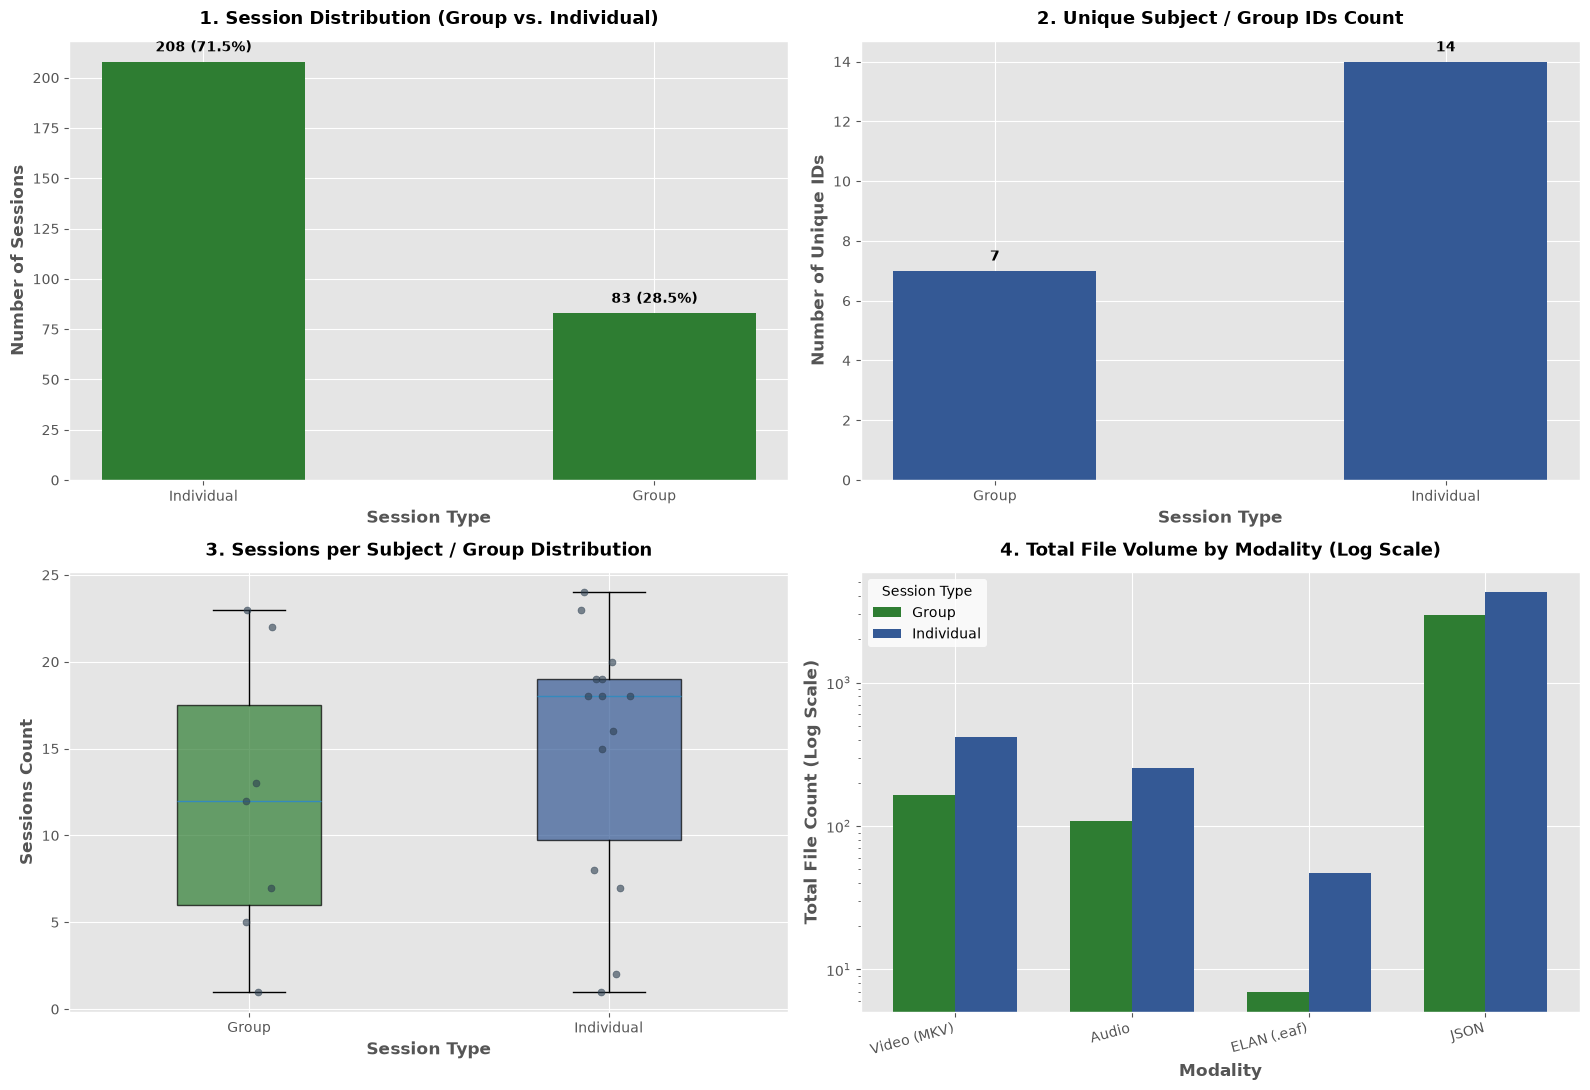

In [21]:
plt.style.use('ggplot')

# ============================================================
# 1. CLASSIFY PARTICIPANT TYPE
# ============================================================
def classify_participant_type(child_id_str):
    if pd.isna(child_id_str):
        return "Unknown"
    ids = re.findall(r"\d+", str(child_id_str))
    return "Group" if len(ids) > 1 else "Individual"

df_clean["participant_type"] = df_clean["child_id_canonical"].apply(classify_participant_type)

# Define clean color palette
colors = ['#2E7D32', '#345995', '#E67E22', '#C0392B']

# Setup 2x2 Dashboard Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ------------------------------------------------------------
# 1. Session Distribution (Top-Left)
# ------------------------------------------------------------
counts = df_clean["participant_type"].value_counts()
bars1 = axes[0, 0].bar(counts.index, counts.values, color=colors[0], width=0.45)
axes[0, 0].set_title("1. Session Distribution (Group vs. Individual)", fontweight='bold', fontsize=13, pad=12)
axes[0, 0].set_xlabel("Session Type", fontweight='bold')
axes[0, 0].set_ylabel("Number of Sessions", fontweight='bold')

for bar in bars1:
    height = bar.get_height()
    pct = (height / len(df_clean)) * 100
    axes[0, 0].annotate(f'{int(height)} ({pct:.1f}%)',
                        (bar.get_x() + bar.get_width() / 2., height),
                        ha='center', va='bottom', xytext=(0, 5), 
                        textcoords='offset points', fontweight='bold', fontsize=10)

# ------------------------------------------------------------
# 2. Unique IDs Count (Top-Right)
# ------------------------------------------------------------
type_counts = df_clean.groupby("participant_type")["child_id_canonical"].nunique()
bars2 = axes[0, 1].bar(type_counts.index, type_counts.values, color=colors[1], width=0.45)
axes[0, 1].set_title("2. Unique Subject / Group IDs Count", fontweight='bold', fontsize=13, pad=12)
axes[0, 1].set_xlabel("Session Type", fontweight='bold')
axes[0, 1].set_ylabel("Number of Unique IDs", fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    axes[0, 1].annotate(f'{int(height)}',
                        (bar.get_x() + bar.get_width() / 2., height),
                        ha='center', va='bottom', xytext=(0, 5), 
                        textcoords='offset points', fontweight='bold', fontsize=10)

# ------------------------------------------------------------
# 3. Sessions per Subject / Group (Bottom-Left)
# ------------------------------------------------------------
sessions_per_subject = df_clean.groupby(["participant_type", "child_id_canonical"]).size().reset_index(name="session_count")
categories = sessions_per_subject["participant_type"].unique()
data_to_plot = [sessions_per_subject[sessions_per_subject["participant_type"] == cat]["session_count"] for cat in categories]

bp = axes[1, 0].boxplot(data_to_plot, tick_labels=categories, patch_artist=True, widths=0.4)
for patch, color in zip(bp['boxes'], [colors[0], colors[1]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Scatter jitter overlay
np.random.seed(42)
for i, cat in enumerate(categories):
    y = sessions_per_subject[sessions_per_subject["participant_type"] == cat]["session_count"]
    x = np.random.normal(i + 1, 0.04, size=len(y))
    axes[1, 0].scatter(x, y, color='#2C3E50', alpha=0.6, s=25, zorder=3)

axes[1, 0].set_title("3. Sessions per Subject / Group Distribution", fontweight='bold', fontsize=13, pad=12)
axes[1, 0].set_xlabel("Session Type", fontweight='bold')
axes[1, 0].set_ylabel("Sessions Count", fontweight='bold')

# ------------------------------------------------------------
# 4. Total File Volume by Modality (Bottom-Right)
# ------------------------------------------------------------
modality_cols = ['n_mkv_files', 'n_audio_files', 'n_eaf_files', 'n_json_files']
modality_labels = {
    'n_mkv_files': 'Video (MKV)',
    'n_audio_files': 'Audio',
    'n_eaf_files': 'ELAN (.eaf)',
    'n_json_files': 'JSON'
}

grouped_sum = df_clean.groupby('participant_type')[modality_cols].sum().rename(columns=modality_labels)
modalities = list(modality_labels.values())
participant_types = grouped_sum.index.tolist()

x = np.arange(len(modalities))
width = 0.35

for i, p_type in enumerate(participant_types):
    offset = (i - len(participant_types) / 2 + 0.5) * width
    axes[1, 1].bar(x + offset, grouped_sum.loc[p_type], width, label=p_type, color=colors[i])

axes[1, 1].set_title("4. Total File Volume by Modality (Log Scale)", fontweight='bold', fontsize=13, pad=12)
axes[1, 1].set_xlabel("Modality", fontweight='bold')
axes[1, 1].set_ylabel("Total File Count (Log Scale)", fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(modalities, rotation=15, ha='right')
axes[1, 1].set_yscale("log")
axes[1, 1].legend(title="Session Type", facecolor='white', edgecolor='none')

# Layout adjustment
plt.tight_layout()
plt.show()

In [22]:
# TABLES: DISTRIBUTION OF VIDEO, AUDIO, ANNOTATIONS, BBOXES, ETC.
# ============================================================

total_sessions = len(df_clean)

# 1. Overview of modalities and resource folders
resources_data = [
    {
        "Modality / Resource": "Video (MKV)",
        "Total Count": int(df_clean["n_mkv_files"].sum()),
        "Sessions with Resource": int((df_clean["n_mkv_files"] > 0).sum()),
        "Coverage (%)": round((df_clean["n_mkv_files"] > 0).mean() * 100, 2),
        "Mean / Session": round(df_clean["n_mkv_files"].mean(), 2),
        "Median": float(df_clean["n_mkv_files"].median()),
        "Max": int(df_clean["n_mkv_files"].max())
    },
    {
        "Modality / Resource": "Audio Files",
        "Total Count": int(df_clean["n_audio_files"].sum()),
        "Sessions with Resource": int((df_clean["n_audio_files"] > 0).sum()),
        "Coverage (%)": round((df_clean["n_audio_files"] > 0).mean() * 100, 2),
        "Mean / Session": round(df_clean["n_audio_files"].mean(), 2),
        "Median": float(df_clean["n_audio_files"].median()),
        "Max": int(df_clean["n_audio_files"].max())
    },
    {
        "Modality / Resource": "ELAN Annotations (.eaf)",
        "Total Count": int(df_clean["n_eaf_files"].sum()),
        "Sessions with Resource": int((df_clean["n_eaf_files"] > 0).sum()),
        "Coverage (%)": round((df_clean["n_eaf_files"] > 0).mean() * 100, 2),
        "Mean / Session": round(df_clean["n_eaf_files"].mean(), 2),
        "Median": float(df_clean["n_eaf_files"].median()),
        "Max": int(df_clean["n_eaf_files"].max())
    },
    {
        "Modality / Resource": "JSON Files",
        "Total Count": int(df_clean["n_json_files"].sum()),
        "Sessions with Resource": int((df_clean["n_json_files"] > 0).sum()),
        "Coverage (%)": round((df_clean["n_json_files"] > 0).mean() * 100, 2),
        "Mean / Session": round(df_clean["n_json_files"].mean(), 2),
        "Median": float(df_clean["n_json_files"].median()),
        "Max": int(df_clean["n_json_files"].max())
    },
    {
        "Modality / Resource": "TXT Files",
        "Total Count": int(df_clean["n_txt_files"].sum()),
        "Sessions with Resource": int((df_clean["n_txt_files"] > 0).sum()),
        "Coverage (%)": round((df_clean["n_txt_files"] > 0).mean() * 100, 2),
        "Mean / Session": round(df_clean["n_txt_files"].mean(), 2),
        "Median": float(df_clean["n_txt_files"].median()),
        "Max": int(df_clean["n_txt_files"].max())
    },
    {
        "Modality / Resource": "Bounding Boxes (Folder)",
        "Total Count": "-",
        "Sessions with Resource": int(df_clean["bounding_boxes_folder_available"].sum()),
        "Coverage (%)": round(df_clean["bounding_boxes_folder_available"].mean() * 100, 2),
        "Mean / Session": "-",
        "Median": "-",
        "Max": "-"
    },
    {
        "Modality / Resource": "Skeletons (Folder)",
        "Total Count": "-",
        "Sessions with Resource": int(df_clean["skeletons_folder_available"].sum()),
        "Coverage (%)": round(df_clean["skeletons_folder_available"].mean() * 100, 2),
        "Mean / Session": "-",
        "Median": "-",
        "Max": "-"
    },
    {
        "Modality / Resource": "Visualizations (Folder)",
        "Total Count": "-",
        "Sessions with Resource": int(df_clean["Visualizations_folder_available"].sum()),
        "Coverage (%)": round(df_clean["Visualizations_folder_available"].mean() * 100, 2),
        "Mean / Session": "-",
        "Median": "-",
        "Max": "-"
    },
    {
        "Modality / Resource": "ReID Config (JSON)",
        "Total Count": "-",
        "Sessions with Resource": int(df_clean["config_reid_json_available"].sum()),
        "Coverage (%)": round(df_clean["config_reid_json_available"].mean() * 100, 2),
        "Mean / Session": "-",
        "Median": "-",
        "Max": "-"
    }
]

df_resource_summary = pd.DataFrame(resources_data)

print("\n" + "="*75)
print(" TABLE 5: Detailed Dataset Resource Distribution ")
print("="*75)
print(df_resource_summary.to_string(index=False))

# 2. Detailed comparative analysis: Group vs Individual
group_ind_summary = df_clean.groupby("participant_type").agg(
    Session_Count=("session_id", "count"),
    Unique_IDs=("child_id_canonical", "nunique"),
    Total_MKV=("n_mkv_files", "sum"),
    Mean_MKV=("n_mkv_files", "mean"),
    Total_Audio=("n_audio_files", "sum"),
    Mean_Audio=("n_audio_files", "mean"),
    Total_EAF=("n_eaf_files", "sum"),
    Sessions_with_EAF=("n_eaf_files", lambda x: (x > 0).sum()),
    Total_JSON=("n_json_files", "sum"),
    Sessions_with_BBoxes=("bounding_boxes_folder_available", "sum"),
    Sessions_with_Skeletons=("skeletons_folder_available", "sum"),
    Sessions_with_ReID=("config_reid_json_available", "sum")
).T

print("\n" + "="*75)
print(" TABLE 6: Resource Comparison (Group vs. Individual) ")
print("="*75)
print(group_ind_summary.round(2))



 TABLE 5: Detailed Dataset Resource Distribution 
    Modality / Resource Total Count  Sessions with Resource  Coverage (%) Mean / Session Median   Max
            Video (MKV)         582                     290         99.66            2.0    2.0     4
            Audio Files         363                     288         98.97           1.25    1.0     3
ELAN Annotations (.eaf)          54                      30         10.31           0.19    0.0     4
             JSON Files        7233                     287         98.63          24.86    1.0  2886
              TXT Files       48908                      36         12.37         168.07    0.0 11917
Bounding Boxes (Folder)           -                       5          1.72              -      -     -
     Skeletons (Folder)           -                       5          1.72              -      -     -
Visualizations (Folder)           -                       1          0.34              -      -     -
     ReID Config (JSON)        